# Replication Results

This notebook presents the core replication outputs: **Table 1**
(trading performance statistics) and **Figure 5** (cumulative
portfolio returns).  Results are compared against the original
paper's findings.

---
## Differences from the Original Study

While the replication pipeline closely follows the paper, several
important differences arise:

1. **Headline source** -- The original study uses RavenPack headline
   text directly.  This replication instead uses independently scraped
   headlines (from PR Newswire and GDELT) that are fuzzy-matched
   against RavenPack to obtain entity metadata (tickers, relevance
   scores, deduplication keys).  The scraped headlines can be sent to
   OpenAI without violating RavenPack's data licensing restrictions.
   Coverage differences may result in a different headline count.

2. **Overnight only** -- The replication focuses on the overnight
   component of the strategy and does not attempt to reproduce the
   intraday results.

3. **Model deprecation** -- The exact GPT-4 model used in the paper
   (`gpt-4-0314`) has been deprecated.  To avoid look-ahead bias,
   the replication uses GPT-3.5-Turbo, whose training data end prior
   to the sample period.  This model appears to classify headlines
   more conservatively, producing a much larger share of UNKNOWN
   labels (~67% vs ~35%).

4. **Smaller portfolios** -- Fewer headlines and more neutral
   classifications mean fewer firms appear in the daily portfolios.

---
## Setup

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

from settings import config

DATA_DIR = Path(config("DATA_DIR"))
OUTPUT_DIR = Path(config("OUTPUT_DIR"))
MANUAL_DATA_DIR = Path(config("MANUAL_DATA_DIR"))

---
## Table 1: Original Paper Results

The table below reproduces Table 1 from the original paper
(Lopez-Lira and Tang, 2023).  Only the overnight columns are shown,
as the replication focuses on overnight signals.

| | Initial Reaction | | Sharpe |
|---|---|---|---|
| **Portfolio** | **Hit Rate (%)** | **Mean Return (%)** | **Ratio** |
| Long-Short | 93.28 | 3.06 | 2.97 |
| Long-Only | 83.28 | 1.27 | 0.78 |
| Short-Only | 79.40 | 1.79 | 2.01 |
| | | | |
| Firm-Day Obs. | 105,742 | | |
| Trading Days | 670 | | |

---
## Table 1: Replication (Paper Sample, Oct 2021 -- May 2024)

In [2]:
paper_sample_path = OUTPUT_DIR / "table1_overnight_paper_sample.csv"
paper_summary_path = OUTPUT_DIR / "table1_summary_paper_sample.csv"
if paper_sample_path.exists():
    paper_sample = pd.read_csv(paper_sample_path)
    display(Markdown("### Replication -- Paper Sample Period"))
    display(paper_sample)

if paper_summary_path.exists():
    paper_summary = pd.read_csv(paper_summary_path).iloc[0]
    display(
        Markdown(
            f"**Trading Days:** {paper_summary['Trading Days']:,.0f} | "
            f"**Firm-Day Observations:** {paper_summary['Firm-Day Observations']:,.0f}"
        )
    )

### Replication -- Paper Sample Period

,Portfolio,Initial Reaction Hit Rate (%),Initial Reaction Mean Return (%),Drift Hit Rate (%),Drift Mean Return (%),Drift Sharpe Ratio
0,Long-Short Portfolio,76.162,3.609,48.876,0.064,0.209
1,Long-Only Portfolio,71.642,1.779,46.269,0.036,0.214
2,Short-Only Portfolio,70.309,4.838,50.103,0.008,0.020


**Trading Days:** 670 | **Firm-Day Observations:** 35,113

The replication broadly reproduces the qualitative pattern from the
paper.  The long-short portfolio generates positive drift returns and
an economically meaningful Sharpe ratio.  However, the magnitude is
lower than in the original study, consistent with the smaller
portfolio sizes and higher share of neutral classifications.

---
## Table 1: Replication (Full Sample, through 2026)

In [3]:
full_sample_path = OUTPUT_DIR / "table1_overnight_full_sample.csv"
full_summary_path = OUTPUT_DIR / "table1_summary_full_sample.csv"
if full_sample_path.exists():
    full_sample = pd.read_csv(full_sample_path)
    display(Markdown("### Replication -- Full Sample"))
    display(full_sample)

if full_summary_path.exists():
    full_summary = pd.read_csv(full_summary_path).iloc[0]
    display(
        Markdown(
            f"**Trading Days:** {full_summary['Trading Days']:,.0f} | "
            f"**Firm-Day Observations:** {full_summary['Firm-Day Observations']:,.0f}"
        )
    )

### Replication -- Full Sample

,Portfolio,Initial Reaction Hit Rate (%),Initial Reaction Mean Return (%),Drift Hit Rate (%),Drift Mean Return (%),Drift Sharpe Ratio
0,Long-Short Portfolio,77.087,5.175,49.072,-0.059,-0.196
1,Long-Only Portfolio,72.442,3.294,46.452,-0.037,-0.192
2,Short-Only Portfolio,70.867,5.280,51.897,0.162,0.392


**Trading Days:** 1,088 | **Firm-Day Observations:** 53,880

Hit ratios for the long-short, long, and short portfolios remain
high and comparable to the original paper.  Sharpe ratios decrease
both relative to the paper and relative to the paper-window
replication, reflecting a trend observed in the paper that strategy
returns decline over time following the introduction of LLM models
(see Table OA2 in the original paper).

---
## Replication Comparison

Below we compute the difference and percentage error between our
paper-sample replication and the original paper's Table 1.

In [4]:
actual_path = MANUAL_DATA_DIR / "paper_table1.csv"
actual_summary_path = MANUAL_DATA_DIR / "paper_table1_summary.csv"
if paper_sample_path.exists() and actual_path.exists():
    actual = pd.read_csv(actual_path)
    paper_sample = pd.read_csv(paper_sample_path)

    compare_cols = [c for c in paper_sample.columns if c in actual.columns]
    numeric_cols = [c for c in compare_cols if c != "Portfolio"]

    actual_cmp = actual[compare_cols].set_index("Portfolio")
    paper_cmp = paper_sample[compare_cols].set_index("Portfolio")

    diff = paper_cmp[numeric_cols].apply(pd.to_numeric, errors="coerce") - actual_cmp[
        numeric_cols
    ].apply(pd.to_numeric, errors="coerce")

    display(Markdown("### Absolute Difference (Replication - Paper)"))
    display(diff.reset_index().style.format({c: "{:.4f}" for c in numeric_cols}))

    pct_error = pd.DataFrame(index=actual_cmp.index)
    for col in numeric_cols:
        a = pd.to_numeric(actual_cmp[col], errors="coerce")
        r = pd.to_numeric(paper_cmp[col], errors="coerce")
        pct_error[f"{col} (%)"] = ((r - a) / a.replace(0, pd.NA)) * 100

    display(Markdown("### Percentage Error"))
    error_cols = pct_error.columns.tolist()
    display(
        pct_error.reset_index().style.format({c: "{:.2f}%" for c in error_cols})
    )

if paper_summary_path.exists() and actual_summary_path.exists():
    paper_sum = pd.read_csv(paper_summary_path).iloc[0]
    actual_sum = pd.read_csv(actual_summary_path).iloc[0]
    display(
        Markdown(
            f"**Sample comparison** -- "
            f"Trading Days: {paper_sum['Trading Days']:,.0f} "
            f"(paper: {actual_sum['Trading Days']:,.0f}) | "
            f"Firm-Day Obs: {paper_sum['Firm-Day Observations']:,.0f} "
            f"(paper: {actual_sum['Firm-Day Observations']:,.0f})"
        )
    )

### Absolute Difference (Replication - Paper)

,Portfolio,Initial Reaction Hit Rate (%),Initial Reaction Mean Return (%),Drift Hit Rate (%),Drift Mean Return (%),Drift Sharpe Ratio
0,Long-Short Portfolio,-17.1180,0.5490,-9.1840,-0.2760,-2.7610
1,Long-Only Portfolio,-11.6380,0.5090,-4.6310,-0.0440,-0.5660
2,Short-Only Portfolio,-9.0910,3.0480,-3.4770,-0.2520,-1.9900


### Percentage Error

,Portfolio,Initial Reaction Hit Rate (%) (%),Initial Reaction Mean Return (%) (%),Drift Hit Rate (%) (%),Drift Mean Return (%) (%),Drift Sharpe Ratio (%)
0,Long-Short Portfolio,-18.35%,17.94%,-15.82%,-81.18%,-92.96%
1,Long-Only Portfolio,-13.97%,40.08%,-9.10%,-55.00%,-72.56%
2,Short-Only Portfolio,-11.45%,170.28%,-6.49%,-96.92%,-99.00%


**Sample comparison** -- Trading Days: 670 (paper: 670) | Firm-Day Obs: 35,113 (paper: 105,742)

The largest discrepancies appear in the drift and Sharpe ratio
columns.  This can almost certainly be attributed to the use of
GPT-3.5-Turbo instead of GPT-4.  The older model produces
significantly more UNKNOWN responses (~67% vs ~35%), which reduces
the number of actionable signals and weakens the strategy's
performance.

---
## Figure 5: Cumulative Returns (Paper Sample)

### Figure 5 -- Paper Sample

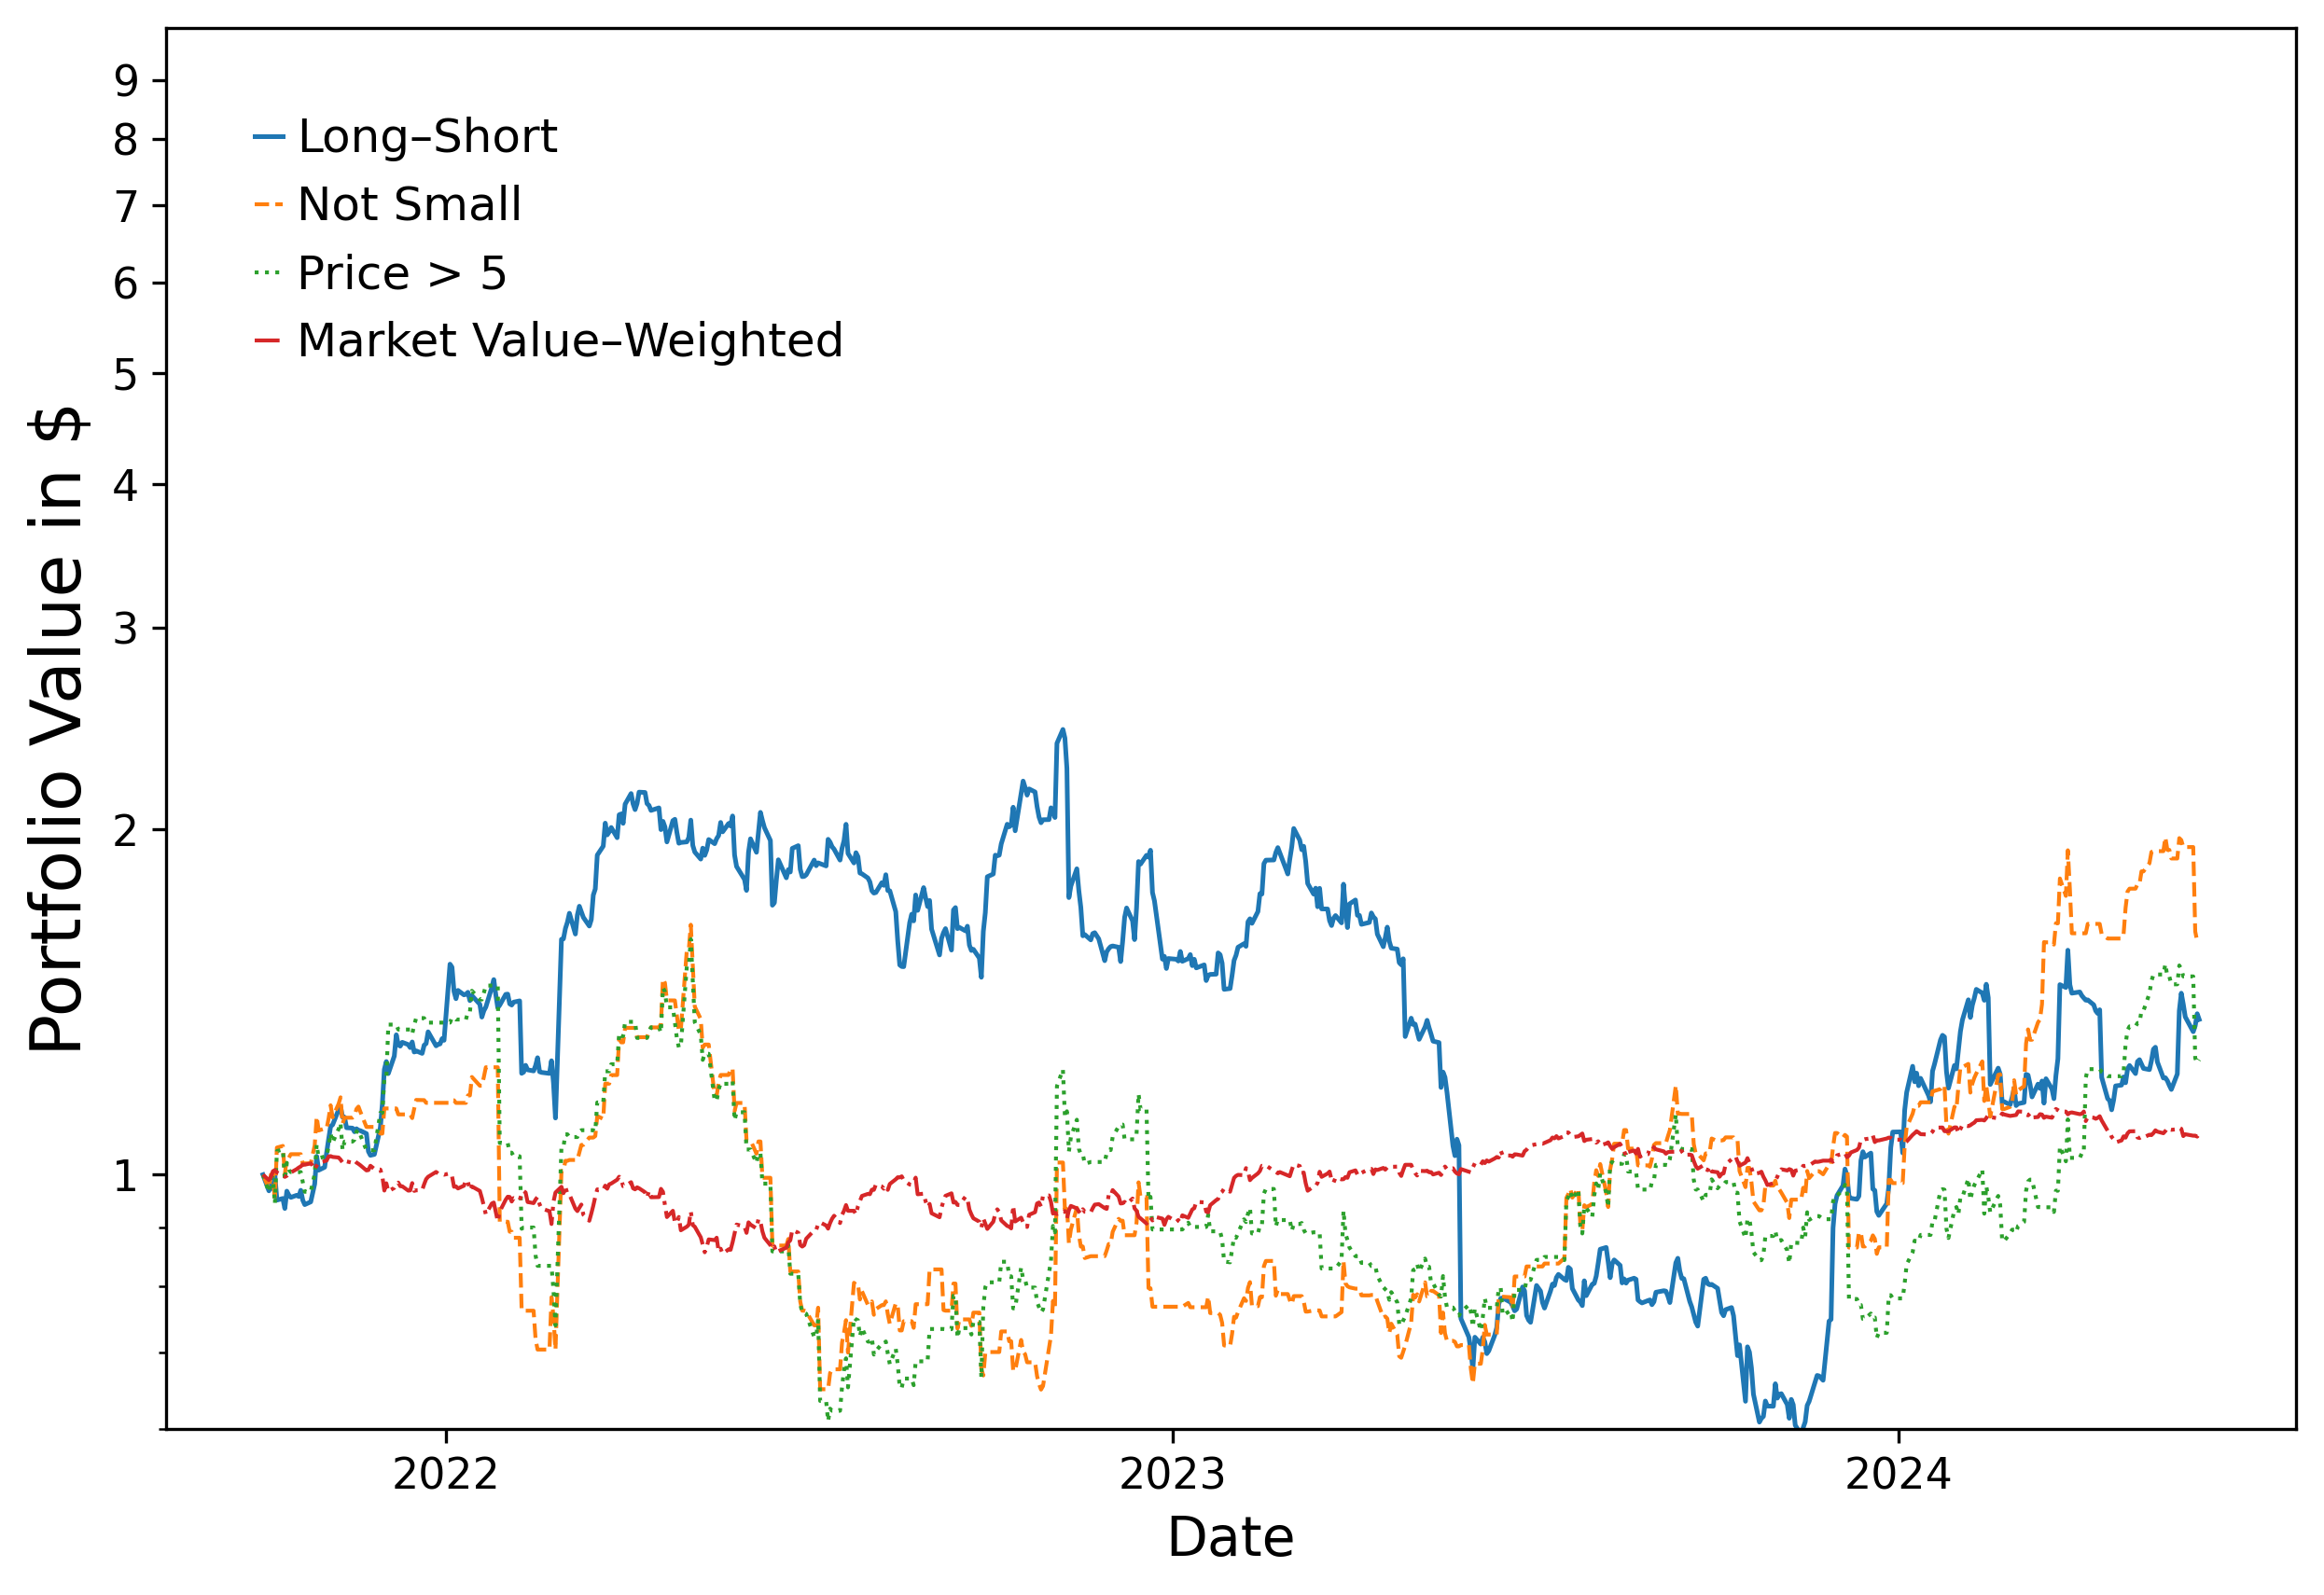

In [5]:
import create_figure5 as cf5

port_path = DATA_DIR / "portfolio_daily_returns.parquet"
if port_path.exists():
    df = pd.read_parquet(port_path)

    # Paper sample window
    df_paper = df.copy()
    df_paper["date"] = pd.to_datetime(df_paper["date"], errors="coerce")
    df_paper = df_paper[
        (df_paper["date"] >= cf5.PAPER_START) & (df_paper["date"] <= cf5.PAPER_END)
    ]

    paper_series = cf5.prepare_series(df_paper)
    cf5.make_plot(paper_series, OUTPUT_DIR / "figure5_paper_sample.png")

    from IPython.display import Image

    display(Markdown("### Figure 5 -- Paper Sample"))
    display(Image(filename=str(OUTPUT_DIR / "figure5_paper_sample.png"), width=700))

The cumulative return profile remains positive over the sample
period.  Although the growth rate is lower than the original paper,
the general pattern of sustained positive returns is preserved.

The Not-Small and Price > 5 variants fluctuate more than in the
original figure, likely due to the decreased number of stocks in
the portfolios from the higher rate of UNKNOWN classifications.

---
## Figure 5: Cumulative Returns (Full Sample)

### Figure 5 -- Full Sample

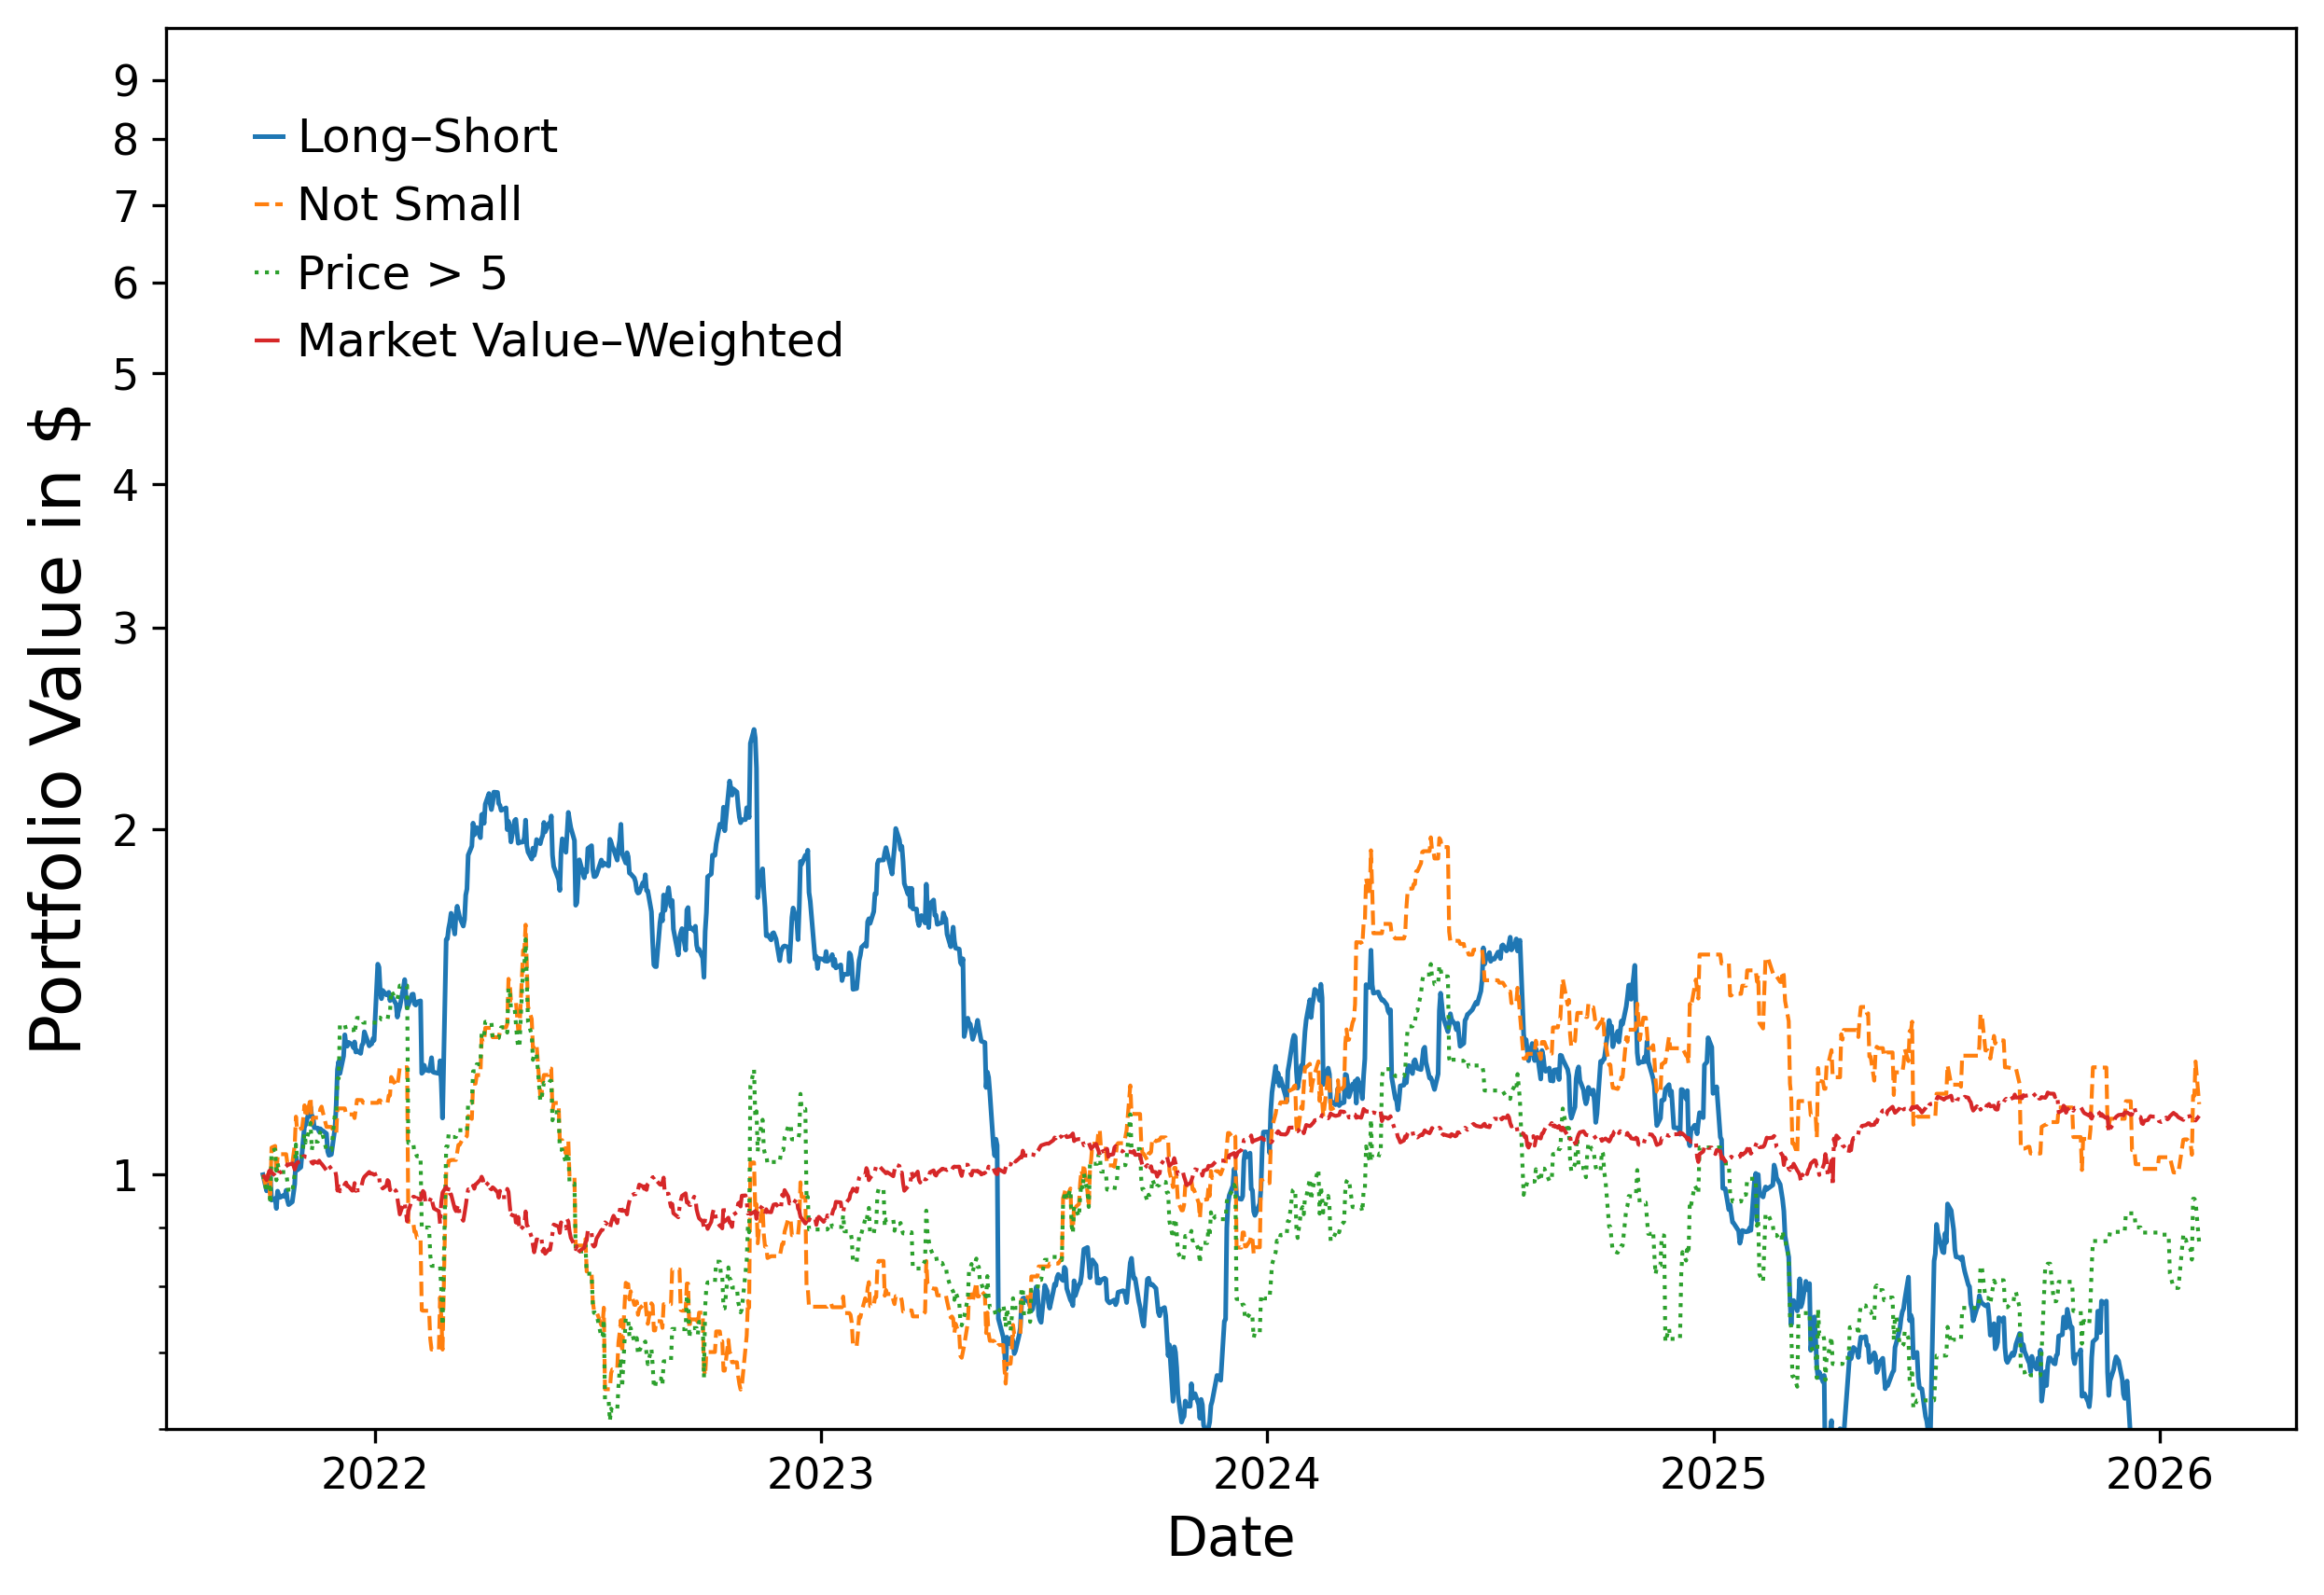

In [6]:
if port_path.exists():
    full_series = cf5.prepare_series(df)
    cf5.make_plot(full_series, OUTPUT_DIR / "figure5_full_sample.png")

    display(Markdown("### Figure 5 -- Full Sample"))
    display(Image(filename=str(OUTPUT_DIR / "figure5_full_sample.png"), width=700))

Returns appear less stable in 2025-2026 than in previous years,
consistent with the declining Sharpe ratios observed in the full-
sample Table 1 results.

---
## Conclusion

The replication successfully reproduces the central empirical finding
of the original paper: language-model interpretations of financial
news headlines contain predictive information about stock returns.
The long-short strategy based on these signals continues to generate
positive drift returns and economically meaningful Sharpe ratios.

At the same time, the replication reveals differences in magnitude.
Portfolio sizes are smaller, cumulative returns grow more slowly, and
the model assigns a much larger fraction of headlines to UNKNOWN.
These differences arise primarily from the use of GPT-3.5-Turbo
(vs GPT-4) and from the use of independently scraped headlines
(rather than RavenPack's headline text) as the input to the model.

Despite these differences, the replication confirms that large
language models can extract useful financial signals from news
headlines and translate them into profitable trading strategies.